# Import and Preprocess data

In [1]:
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

print('Training data shape:', train_images.shape)
print('Testing data shape:', test_images.shape)


KeyboardInterrupt: 

## Preview

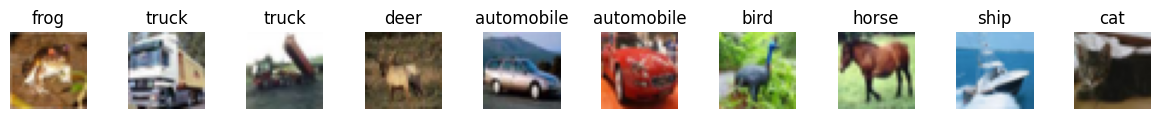

In [ ]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 10, figsize=(15, 1))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i])
    ax.set_title(class_names[train_labels[i][0]])
    ax.axis('off')
plt.show()


## Map (Normalize could be better)

In [ ]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

## One-hot encoding

In [ ]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

# Model Architecture

In [ ]:
# Build the CNN Model (Sequential)
model = keras.Sequential()

In [ ]:
# Define Input Shape
model.add(keras.Input(shape=(32, 32, 3)))

In [ ]:
from tensorflow.keras import layers

# First Convolutional Layer
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))

In [ ]:
# Apply Batch Normalization
model.add(layers.BatchNormalization())

In [ ]:
# Add Max Pooling Layer
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

In [ ]:
# Add Dropout Layer (25%)
model.add(layers.Dropout(rate=0.25))

In [ ]:
# Second Convolutional Block
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(rate=0.25))

In [ ]:
# Third Convolutional Block
model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(rate=0.25))

In [ ]:
# Flatten Feature Maps
model.add(layers.Flatten())

In [ ]:
# Fully Connected Layer (512 units)
model.add(layers.Dense(units=512, activation='relu'))

In [ ]:
# Batch Normalization and Dropout (50%) for Dense Layer
model.add(layers.BatchNormalization())
model.add(layers.Dropout(rate=0.5))

In [ ]:
# Output Layer (10 Classes, Softmax)
model.add(layers.Dense(units=10, activation='softmax'))

In [ ]:
# Build Complete CNN Model (Sequential)
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(rate=0.25),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(rate=0.25),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(rate=0.25),

    layers.Flatten(),
    layers.Dense(units=512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.5),
    layers.Dense(units=10, activation='softmax')
])

# Train the model

In [ ]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the Model
history = model.fit(train_images, train_labels,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 260ms/step - accuracy: 0.3135 - loss: 2.3228 - val_accuracy: 0.2028 - val_loss: 3.0600
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 261ms/step - accuracy: 0.5044 - loss: 1.4098 - val_accuracy: 0.3702 - val_loss: 1.8569
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 94s 266ms/step - accuracy: 0.5544 - loss: 1.2483 - val_accuracy: 0.6144 - val_loss: 1.0881
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 271ms/step - accuracy: 0.5979 - loss: 1.1265 - val_accuracy: 0.6040 - val_loss: 1.1365
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.6293 - loss: 1.0465 - val_accuracy: 0.6628 - val_loss: 0.9752
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.6542 - loss: 0.9860 - val_accuracy: 0.6048 - val_loss: 1.1517
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 94s 266ms/step - accuracy: 0.6659 - loss: 0.9410 - val_accuracy: 0.6922 - val_loss: 0.8651
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 92s 263ms/step - accuracy: 0.6822 - loss:

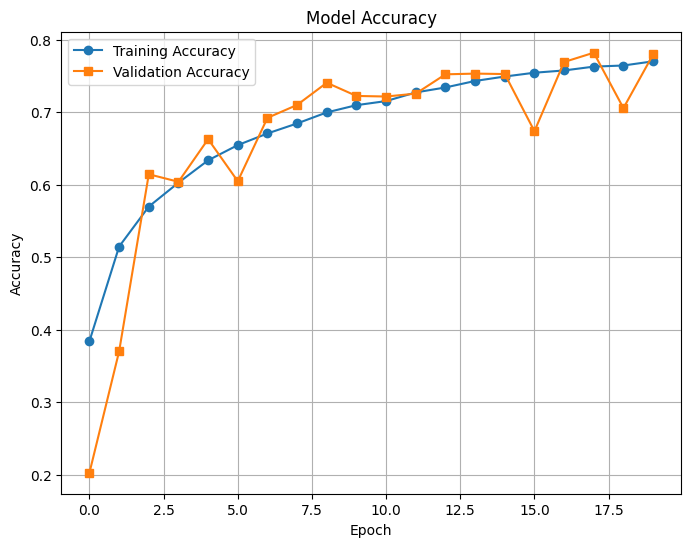

In [ ]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

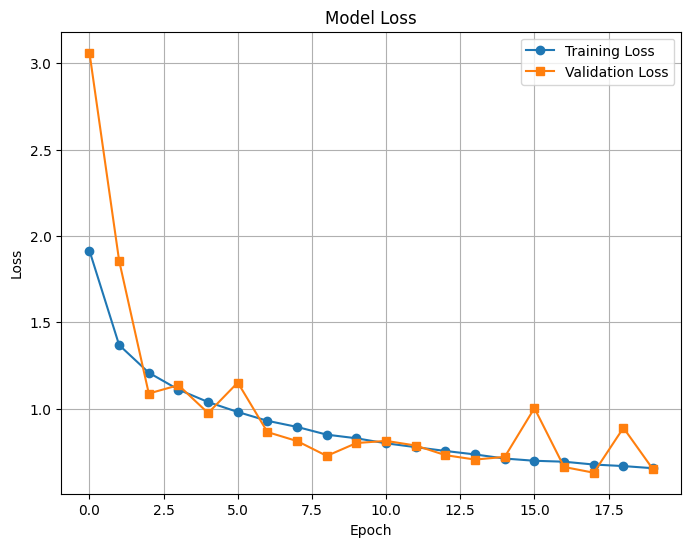

In [ ]:
# Plot Training and Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate

In [ ]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7712 - loss: 0.6797
Test Accuracy: 0.7688
